# Kilian (2007) Full-extension: Bayesian VAR Model

This notebook extends the original data workflow by estimating a Bayesian VAR with NIW prior and Gibbs sampling with extended data (2008-2025).

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

BASE_DIR = Path("./data/")

## Load the Kilian VAR data

### The CPI data of 2025 oct is NaN because the government shutdown in 2025, so we truncate the series before 2025 october

In [2]:
df_old = pd.read_excel(BASE_DIR / 'data_1973_2007.xlsx')

# Convert obs like 1973M02 -> monthly datetime index (1973-02-01)
df_old = df_old.rename(columns={'dprod': 'd_prod'})
df_old['date'] = pd.to_datetime(
    df_old['obs'].astype(str).str.replace('M', '-', regex=False) + '-01',
    format='%Y-%m-%d'
)

df_old = (
    df_old[['date', 'd_prod', 'rea', 'rpo']]
    .set_index('date')
    .sort_index()
)

df_old.head()

,d_prod,rea,rpo
date,,,
1973-02-01,11.877264,36.064235,-47.999534
1973-03-01,1.419150,41.527016,-48.286474
1973-04-01,1.177711,43.991250,-47.082500
1973-05-01,27.455136,48.105889,-43.857651
1973-06-01,-13.110436,52.033462,-41.571063


In [3]:
df_new = pd.read_csv(BASE_DIR / 'data_extended_2008_2025.csv',
                     parse_dates=['date'], index_col='date')
# Drop Oct/Nov/Dec 2025 so the last rpo NaN (Oct 2025) and trailing months are removed
df_new = df_new[df_new.index < '2025-10-01']   # 2008-01 -> 2025-09

cols = ['d_prod', 'rea', 'rpo']

# Append old (1973-2007) and new (2008-2025) datasets
# keep='last' ensures newer data wins if there is any overlap
df = (
    pd.concat([df_old[cols], df_new[cols]], axis=0)
    .sort_index()
)
df = df[~df.index.duplicated(keep='last')]

df.head(),df.tail(),df.shape


(               d_prod        rea        rpo
 date                                       
 1973-02-01  11.877264  36.064235 -47.999534
 1973-03-01   1.419150  41.527016 -48.286474
 1973-04-01   1.177711  43.991250 -47.082500
 1973-05-01  27.455136  48.105889 -43.857651
 1973-06-01 -13.110436  52.033462 -41.571063,
                d_prod        rea         rpo
 date                                        
 2025-05-01   1.291935 -25.227319 -164.619146
 2025-06-01  15.588897  -2.494234 -156.289244
 2025-07-01   6.183759   5.037654 -154.984964
 2025-08-01   6.464529  14.343198 -159.665539
 2025-09-01  15.695441  20.231109 -161.343980,
 (632, 3))

## Data Summary and diagnostics



In [4]:
print(df.describe())
print(df.isnull().sum())
print(df.isna().sum())


           d_prod         rea         rpo
count  632.000000  632.000000  632.000000
mean     0.859636   -3.396694  -44.254331
std     18.973383   40.728404   75.822428
min   -173.885832 -161.243650 -272.750137
25%     -6.239976  -21.907556 -100.219742
50%      2.544631   -7.113553  -36.679731
75%      9.227303   14.396359   26.662418
max     77.983205  189.479230   90.636602
d_prod    0
rea       0
rpo       0
dtype: int64
d_prod    0
rea       0
rpo       0
dtype: int64


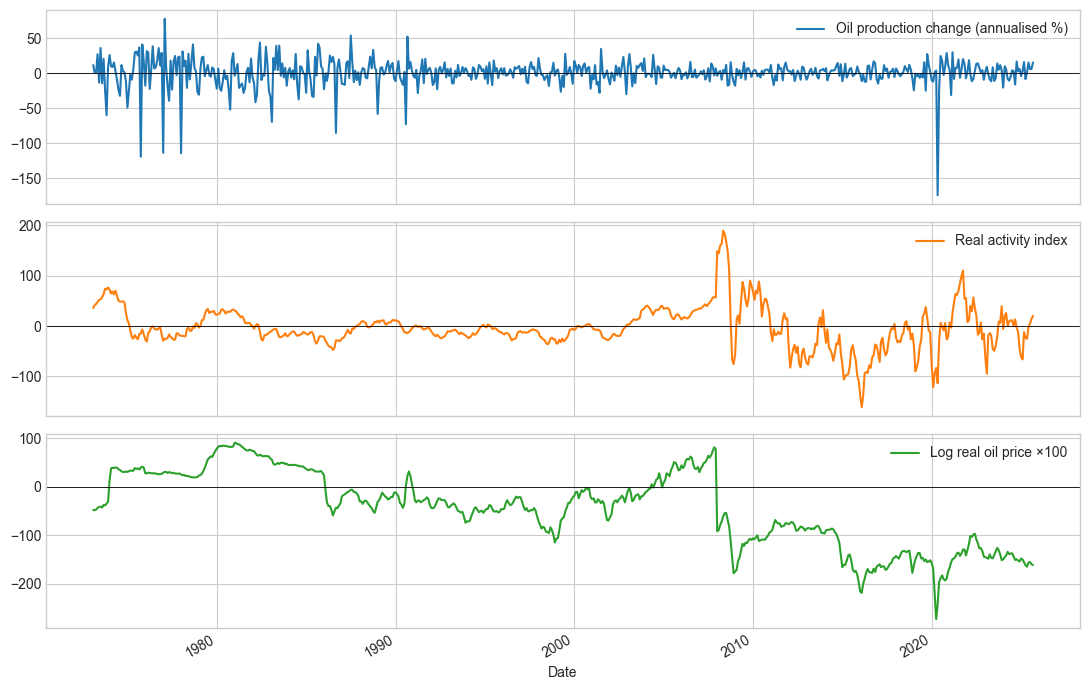

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(df.index, df['d_prod'], label='Oil production change (annualised %)')
axes[0].axhline(0, color='k', lw=0.6)
axes[0].legend()

axes[1].plot(df.index, df['rea'], label='Real activity index', color='tab:orange')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].legend()

axes[2].plot(df.index, df['rpo'], label='Log real oil price ×100', color='tab:green')
axes[2].axhline(0, color='k', lw=0.6)
axes[2].legend()

axes[2].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Stationarity checks (ADF and KPSS)

In [6]:
rows = []
for c in cols:
    s = df[c].dropna().values
    adf = adfuller(s, regression='c', autolag='AIC')
    kps = kpss(s, regression='c', nlags='auto')
    rows.append({
        'series': c,
        'adf_stat': adf[0],
        'adf_pvalue': adf[1],
        'kpss_stat': kps[0],
        'kpss_pvalue': kps[1]
    })
stationarity_table = pd.DataFrame(rows)
stationarity_table

/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_7382/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')
/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_7382/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')
/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_7382/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')


,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
0,d_prod,-6.026682,1.450329e-07,0.036947,0.10
1,rea,-4.417180,2.767273e-04,0.204174,0.10
2,rpo,-1.505072,5.310006e-01,2.619633,0.01


## AIC table by lag length

In [7]:
aic_rows = []
for lag in range(1, 37):
    try:
        res = VAR(df[cols]).fit(lag)
        aic_rows.append({'lag': lag, 'AIC': res.aic})
    except Exception:
        aic_rows.append({'lag': lag, 'AIC': np.nan})
aic_table = pd.DataFrame(aic_rows)
print("Lag with minimum AIC:", aic_table.loc[aic_table['AIC'].idxmin(), 'lag'])
aic_table

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Lag with minimum AIC: 2


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

,lag,AIC
0,1,16.098686
1,2,15.947494
2,3,15.950050
3,4,15.964984
4,5,15.955090
5,6,15.975818
6,7,15.985813
7,8,16.000328
8,9,15.986551
9,10,15.968143


## BVAR(24) with NIW prior and Gibbs sampling

In [8]:
def make_var_regressors(y, p):
    T, n = y.shape
    Y = y[p:, :]
    X_lags = []
    for t in range(p, T):
        row = []
        for L in range(1, p + 1):
            row.extend(y[t - L, :])
        X_lags.append(row)
    X_lags = np.asarray(X_lags)
    X = np.column_stack([np.ones(X_lags.shape[0]), X_lags])
    return Y, X

def draw_matrix_normal(M, V, Sigma, rng):
    k, n = M.shape
    Lv = np.linalg.cholesky(V)
    Ls = np.linalg.cholesky(Sigma)
    Z = rng.standard_normal((k, n))
    return M + Lv @ Z @ Ls.T

def gibbs_bvar_niw(y, p=24, n_draws=12000, burn=2000, seed=42):
    rng = np.random.default_rng(seed)
    Y, X = make_var_regressors(y, p)
    T_eff, n = Y.shape
    k = X.shape[1]

    # NIW prior hyperparameters
    B0 = np.zeros((k, n)) # starting point of the draw is 0
    V0 = np.eye(k) * 10.0 # variance of the prior is 10 %*% I
    V0_inv = np.linalg.inv(V0)
    nu0 = n + 2 # degrees of freedom of the prior
    S0 = np.eye(n) # scale matrix of the prior

    # OLS initialization
    B_ols = np.linalg.inv(X.T @ X) @ (X.T @ Y)
    E_ols = Y - X @ B_ols
    Sigma = (E_ols.T @ E_ols) / T_eff
    B = B_ols.copy()

    keep = n_draws - burn
    B_draws = np.zeros((keep, k, n))
    Sigma_draws = np.zeros((keep, n, n))
    B_trace = np.zeros((n_draws, 4))
    S_trace = np.zeros((n_draws, n))

    XtX = X.T @ X
    XtY = X.T @ Y

    for it in range(n_draws):
        Vn = np.linalg.inv(V0_inv + XtX)
        Bn = Vn @ (V0_inv @ B0 + XtY)
        B = draw_matrix_normal(Bn, Vn, Sigma, rng)

        E = Y - X @ B
        diff = B - B0
        Sn = S0 + E.T @ E + diff.T @ V0_inv @ diff
        nun = nu0 + T_eff + k
        Sigma = invwishart.rvs(df=nun, scale=Sn, random_state=rng)

        B_trace[it, :] = [B[0,0], B[1,0], B[1,1], B[2,2]]
        S_trace[it, :] = np.diag(Sigma)

        if it >= burn:
            j = it - burn
            B_draws[j] = B
            Sigma_draws[j] = Sigma

    out = {
        'Y': Y, 'X': X,
        'B_draws': B_draws,
        'Sigma_draws': Sigma_draws,
        'B_mean': B_draws.mean(axis=0),
        'Sigma_mean': Sigma_draws.mean(axis=0),
        'B_trace': B_trace,
        'S_trace': S_trace
    }
    return out

p = 24
n_draws = 12000
burn = 2000

# df[cols].values produces a pure float64 array — required for matrix arithmetic
bvar = gibbs_bvar_niw(df[cols].values.astype(float), p=p, n_draws=n_draws, burn=burn, seed=42)
bvar['B_mean'].shape, bvar['Sigma_mean']

((73, 3),
 array([[286.7751,   7.9039, -17.3809],
        [  7.9039, 180.5206, -16.0293],
        [-17.3809, -16.0293,  96.3122]]))

## MCMC trace plots (visual convergence check)

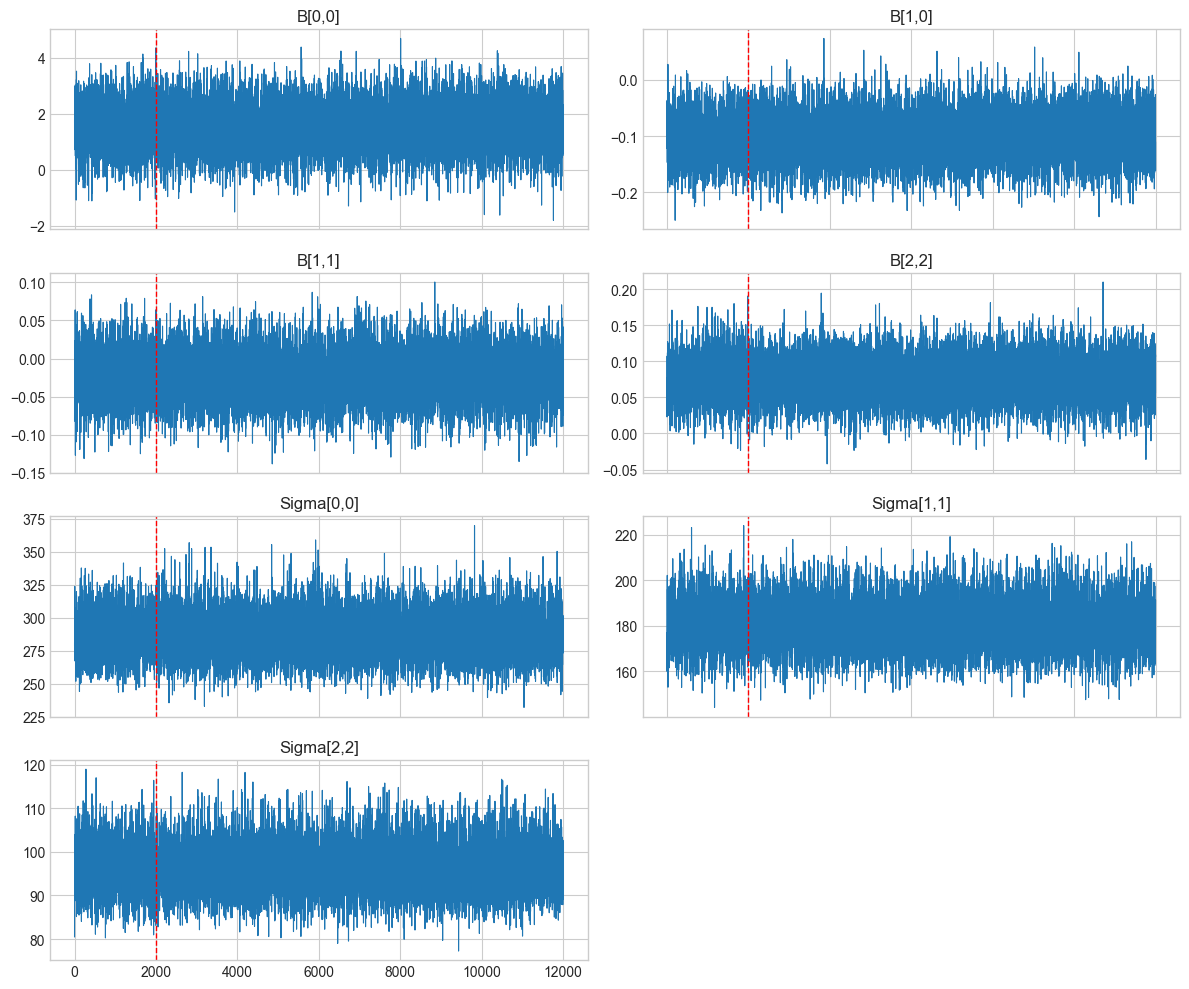

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

trace_names = ['B[0,0]', 'B[1,0]', 'B[1,1]', 'B[2,2]']
for i in range(4):
    axes[i].plot(bvar['B_trace'][:, i], lw=0.8)
    axes[i].axvline(2000, color='r', ls='--', lw=1)
    axes[i].set_title(trace_names[i])

sig_names = ['Sigma[0,0]', 'Sigma[1,1]', 'Sigma[2,2]']
for i in range(3):
    axes[4+i].plot(bvar['S_trace'][:, i], lw=0.8)
    axes[4+i].axvline(2000, color='r', ls='--', lw=1)
    axes[4+i].set_title(sig_names[i])

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Residual diagnostics (Ljung-Box test)

In [10]:
Y = bvar['Y']
X = bvar['X']
Bhat = bvar['B_mean']
resid = Y - X @ Bhat

lb_rows = []
for i, c in enumerate(cols):
    lb = acorr_ljungbox(resid[:, i], lags=[12], return_df=True)
    lb_rows.append({
        'series': c,
        'lb_stat_lag12': float(lb['lb_stat'].iloc[0]),
        'lb_pvalue_lag12': float(lb['lb_pvalue'].iloc[0])
    })
ljung_box_table = pd.DataFrame(lb_rows)
ljung_box_table

,series,lb_stat_lag12,lb_pvalue_lag12
0,d_prod,2.328304,0.998711
1,rea,0.832569,0.999995
2,rpo,0.118393,1.000000


## Running posterior mean over iterations

This plots the cumulative posterior mean (after burn-in) to visually inspect stabilization over MCMC draws.

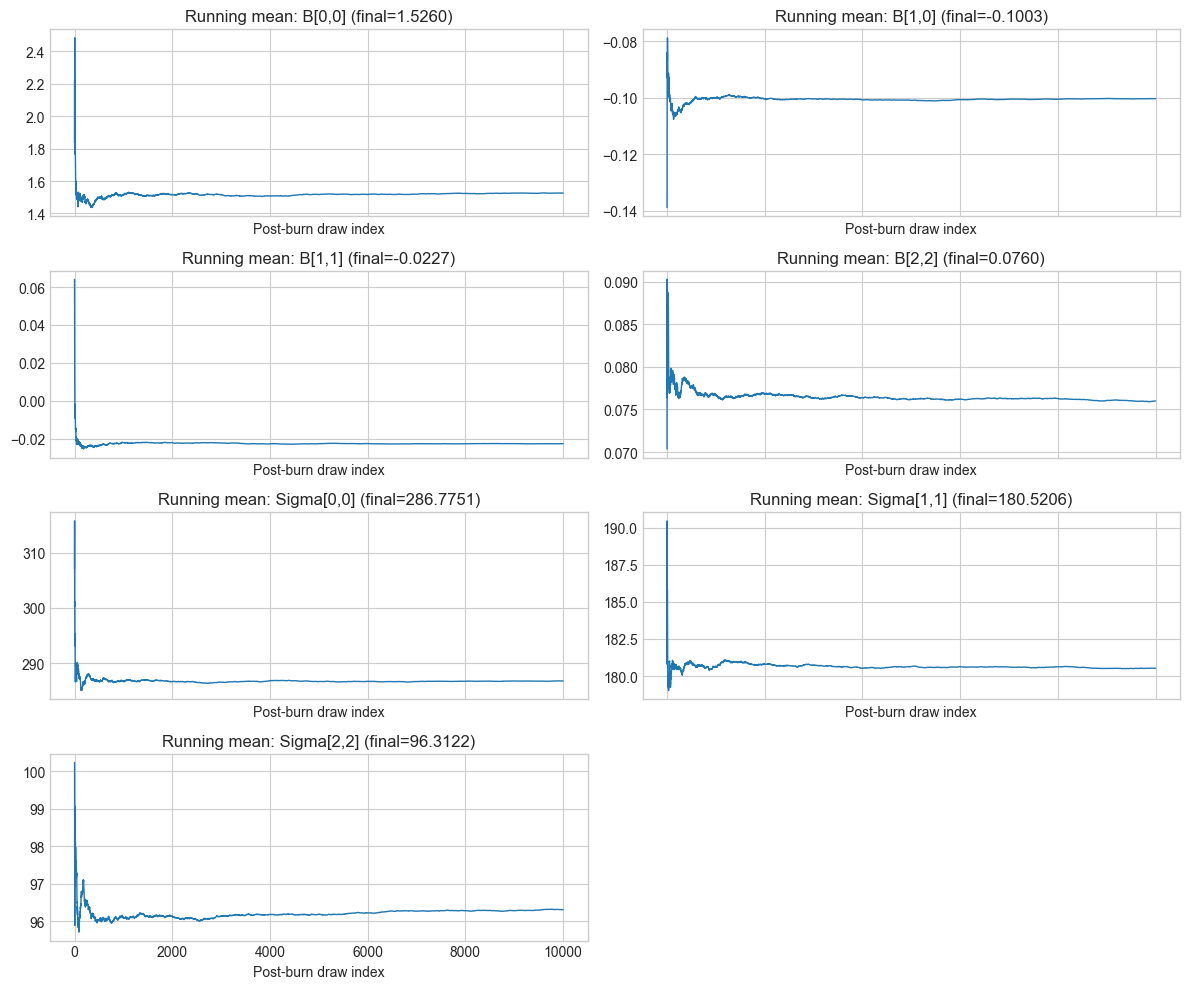

In [11]:
keep_B = bvar['B_draws']
keep_S = bvar['Sigma_draws']

cum_mean_B00 = np.cumsum(keep_B[:, 0, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B10 = np.cumsum(keep_B[:, 1, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B11 = np.cumsum(keep_B[:, 1, 1]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B22 = np.cumsum(keep_B[:, 2, 2]) / np.arange(1, keep_B.shape[0] + 1)

cum_mean_S00 = np.cumsum(keep_S[:, 0, 0]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S11 = np.cumsum(keep_S[:, 1, 1]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S22 = np.cumsum(keep_S[:, 2, 2]) / np.arange(1, keep_S.shape[0] + 1)

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

series = [
    (cum_mean_B00, 'Running mean: B[0,0]'),
    (cum_mean_B10, 'Running mean: B[1,0]'),
    (cum_mean_B11, 'Running mean: B[1,1]'),
    (cum_mean_B22, 'Running mean: B[2,2]'),
    (cum_mean_S00, 'Running mean: Sigma[0,0]'),
    (cum_mean_S11, 'Running mean: Sigma[1,1]'),
    (cum_mean_S22, 'Running mean: Sigma[2,2]'),
]

for i, (s, ttl) in enumerate(series):
    axes[i].plot(s, lw=1)
    axes[i].set_title(f"{ttl} (final={s[-1]:.4f})")
    axes[i].set_xlabel('Post-burn draw index')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [12]:
def bvar_state_matrices(B_mat, n=3, p=24):
    """Convert B matrix (k x n) into intercept and companion A."""
    c = B_mat[0, :]  # intercept (n,)
    A_top = B_mat[1:, :].T  # (n, n*p)
    if p == 1:
        A_comp = A_top
    else:
        bottom = np.hstack([np.eye(n * (p - 1)), np.zeros((n * (p - 1), n))])
        A_comp = np.vstack([A_top, bottom])
    return c, A_top, A_comp


def irf_from_companion(A_comp, Sigma, n=3, p=24, h=15):
    """Cholesky-identified IRFs as (n^2, h+1) stacked by columns."""
    J = np.hstack([np.eye(n), np.zeros((n, n * p - n))])
    C = np.linalg.cholesky(Sigma).T
    comp_power = np.eye(n * p)
    irfs = []
    for _ in range(h + 1):
        resp = J @ comp_power @ J.T @ C
        irfs.append(resp.reshape(n * n, 1, order='F'))
        comp_power = comp_power @ A_comp
    return np.hstack(irfs)


def make_var_xy(y, p):
    """Build Y, X with X=[1, y_{t-1},...,y_{t-p}] consistent with notebook ordering."""
    T, n = y.shape
    Y = y[p:, :]
    X_lags = []
    for t in range(p, T):
        row = []
        for L in range(1, p + 1):
            row.extend(y[t - L, :])
        X_lags.append(row)
    X = np.column_stack([np.ones(len(X_lags)), np.asarray(X_lags)])
    return Y, X


def structural_shocks_from_bmean(y, B_mean, Sigma_mean, p=24):
    Y, X = make_var_xy(y, p)
    U = (Y - X @ B_mean).T  # n x (T-p)
    C = np.linalg.cholesky(Sigma_mean).T
    Ehat = np.linalg.solve(C, U)
    return Ehat


def stage2irf(y, q_shock, nrep=20000, seed=42):
    y = np.asarray(y).reshape(-1, 1)
    q_shock = np.asarray(q_shock).reshape(-1, 1)
    t = len(q_shock)
    pp = 12

    Z = [np.ones((t - pp, 1))]
    for i in range(pp + 1):
        Z.append(q_shock[pp - i:t - i, :])
    Z = np.hstack(Z)

    y_dep = y[pp:t, :]
    bhat = np.linalg.inv(Z.T @ Z) @ Z.T @ y_dep

    irf1hat = bhat[1:, 0]
    cumirf1hat = np.cumsum(irf1hat)

    rng = np.random.default_rng(seed)
    IRF1 = np.zeros((nrep, 13))
    cumIRF1 = np.zeros((nrep, 13))
    block = 4
    y_len = len(y_dep)

    for j in range(nrep):
        yr_blocks, Zr_blocks = [], []
        n_blocks = int(np.ceil(y_len / block))
        for _ in range(n_blocks):
            pos = int(np.ceil(rng.random() * (y_len - block)))
            start = max(0, min(pos - 1, y_len - block))
            yr_blocks.append(y_dep[start:start + block, :])
            Zr_blocks.append(Z[start:start + block, :])

        yr = np.vstack(yr_blocks)[:y_len, :]
        Zr = np.vstack(Zr_blocks)[:y_len, :]

        br = np.linalg.inv(Zr.T @ Zr) @ Zr.T @ yr
        IRF1[j, :] = br[1:, 0]
        cumIRF1[j, :] = np.cumsum(IRF1[j, :])

    q16, q84 = np.quantile(IRF1, [0.16, 0.84], axis=0)
    q025, q975 = np.quantile(IRF1, [0.025, 0.975], axis=0)
    c16, c84 = np.quantile(cumIRF1, [0.16, 0.84], axis=0)
    c025, c975 = np.quantile(cumIRF1, [0.025, 0.975], axis=0)

    return {
        'irf': irf1hat,
        'irf_68': np.vstack([q16, q84]),
        'irf_95': np.vstack([q025, q975]),
        'cum': cumirf1hat,
        'cum_68': np.vstack([c16, c84]),
        'cum_95': np.vstack([c025, c975]),
    }

## Bayesian Figure 2: structural shocks (posterior mean parameters)

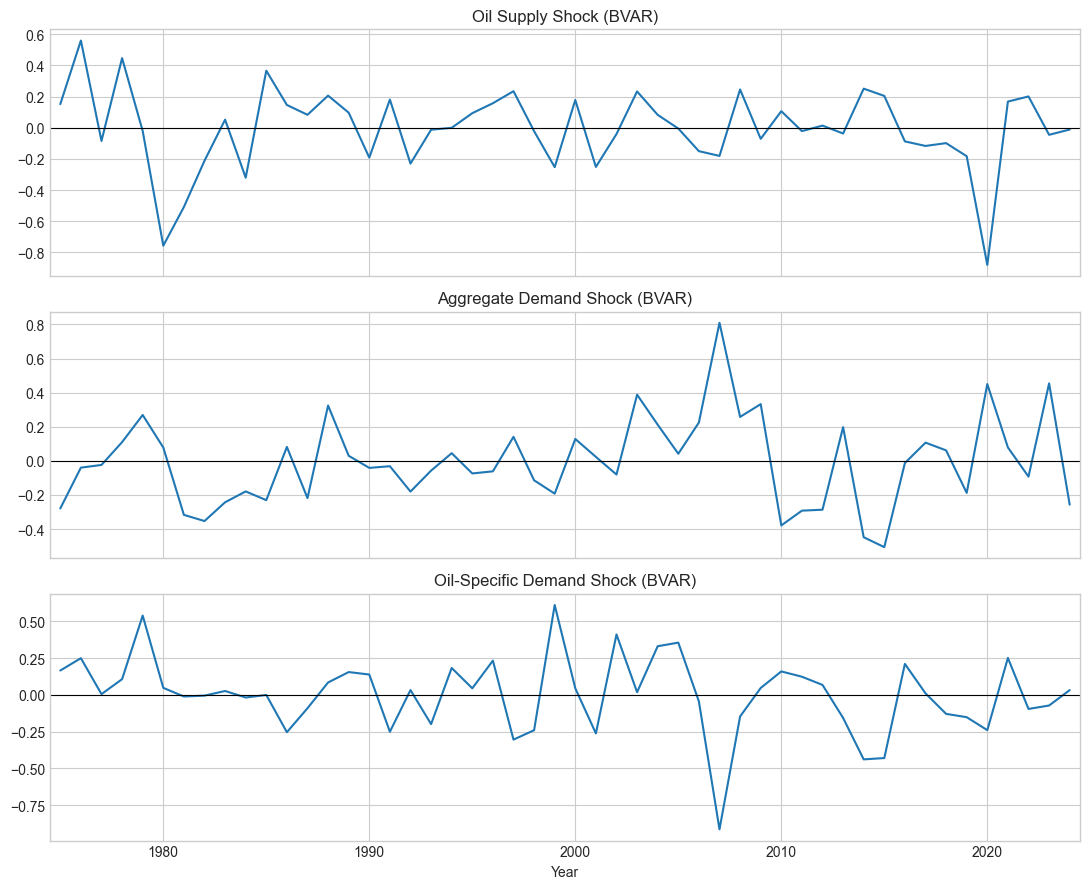

Showing annual averages for 50 complete years (1975–2024)


In [13]:
p = 24
n = 3
h = 15

# Use only numeric columns — df[cols].values is float64
y = df[cols].values.astype(float)
Ehat_b = structural_shocks_from_bmean(y, bvar['B_mean'], bvar['Sigma_mean'], p=p)

# Date axis: shocks start after p lags; df.index[p] is the first observation used
shock_dates = df.index[p:]

# Annual averages of monthly structural shocks
# We can only use complete 12-month blocks
n_shocks = Ehat_b.shape[1]  # number of shock observations available
n_full_years = n_shocks // 12
n_months_to_use = n_full_years * 12

year_min = shock_dates[0].year
time_year = np.arange(year_min, year_min + n_full_years)

def annual_avg(shock_row, n_months):
    """Average monthly shocks over complete years."""
    return shock_row[:n_months].reshape(-1, 12).mean(axis=1)

q1a = annual_avg(Ehat_b[0], n_months_to_use)
q2a = annual_avg(Ehat_b[1], n_months_to_use)
q3a = annual_avg(Ehat_b[2], n_months_to_use)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, s, ttl in zip(
    axes,
    [q1a, q2a, q3a],
    ['Oil Supply Shock (BVAR)', 'Aggregate Demand Shock (BVAR)', 'Oil-Specific Demand Shock (BVAR)']
):
    ax.plot(time_year, s) # use line plot instead
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlim(year_min - 0.5, time_year[-1] + 0.5)
    ax.set_title(ttl)

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

print(f"Showing annual averages for {n_full_years} complete years ({year_min}–{time_year[-1]})")

## Bayesian Figure 3: IRFs and credible intervals from posterior draws

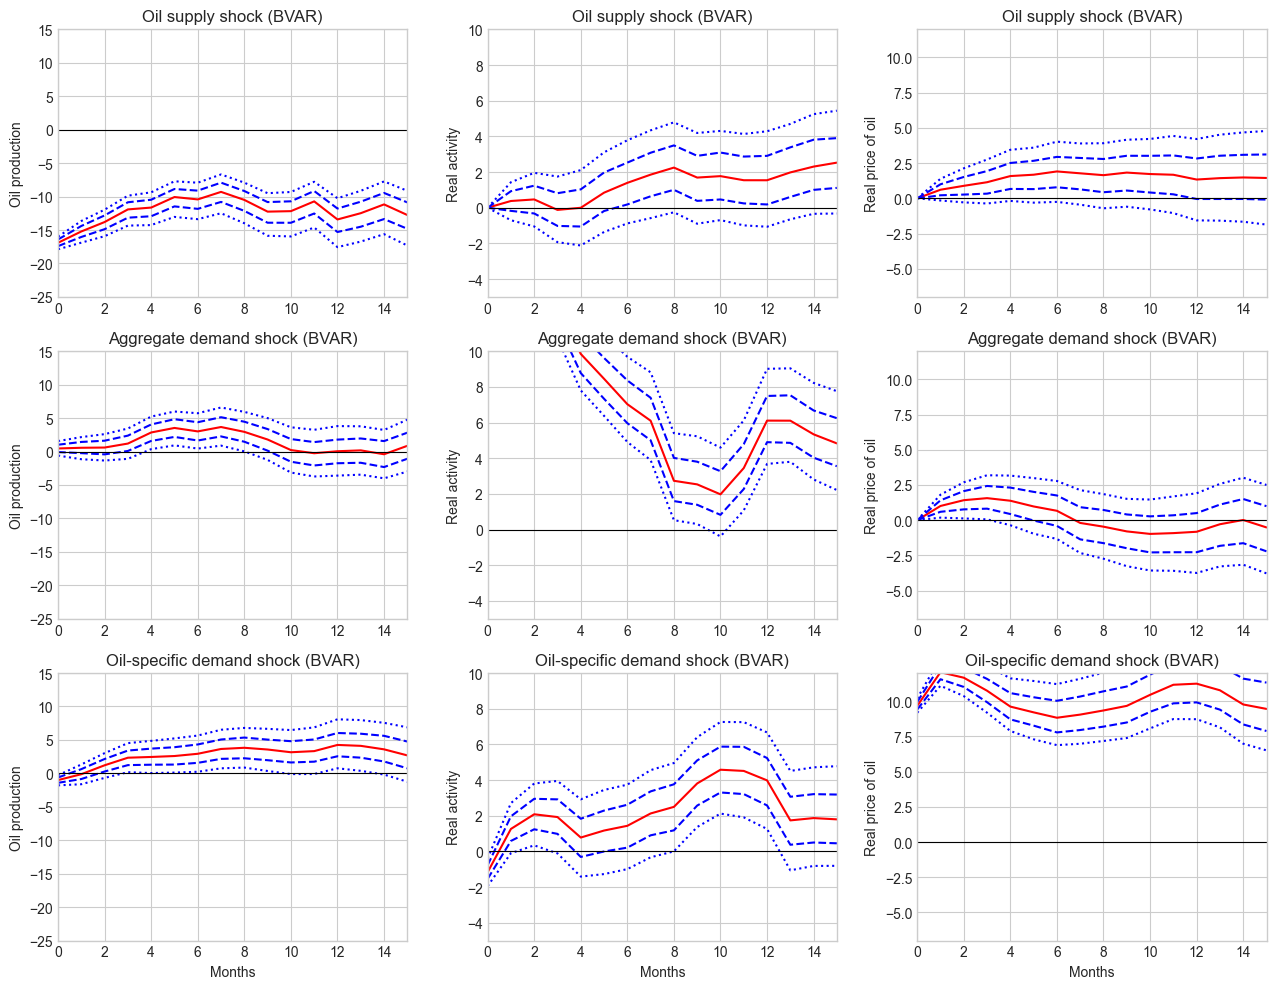

In [14]:
# Posterior draw IRFs for credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

IRF_draws = np.zeros((max_draws, n * n, h + 1))
for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)
    irf_d[0, :] = np.cumsum(irf_d[0, :])
    irf_d[3, :] = np.cumsum(irf_d[3, :])
    irf_d[6, :] = np.cumsum(irf_d[6, :])
    IRF_draws[j] = irf_d

IRF_med = np.median(IRF_draws, axis=0)
IRF_68 = np.quantile(IRF_draws, [0.16, 0.84], axis=0)
IRF_95 = np.quantile(IRF_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production', (-25, 15), -1),
    ('Oil supply shock (BVAR)', 'Real activity', (-5, 10), -1),
    ('Oil supply shock (BVAR)', 'Real price of oil', (-7, 12), -1),
    ('Aggregate demand shock (BVAR)', 'Oil production', (-25, 15), 1),
    ('Aggregate demand shock (BVAR)', 'Real activity', (-5, 10), 1),
    ('Aggregate demand shock (BVAR)', 'Real price of oil', (-7, 12), 1),
    ('Oil-specific demand shock (BVAR)', 'Oil production', (-25, 15), 1),
    ('Oil-specific demand shock (BVAR)', 'Real activity', (-5, 10), 1),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil', (-7, 12), 1),
]

for i, (ttl, yl, ylim, sgn) in enumerate(meta):
    ax = axes[i]
    m = sgn * IRF_med[i]
    l68, u68 = sgn * IRF_68[0, i], sgn * IRF_68[1, i]
    l95, u95 = sgn * IRF_95[0, i], sgn * IRF_95[1, i]
    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax.plot(horizon, m, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(yl)
    ax.set_xlim(0, h)
    ax.set_ylim(*ylim)
    if i >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

# 4.1 FEVD

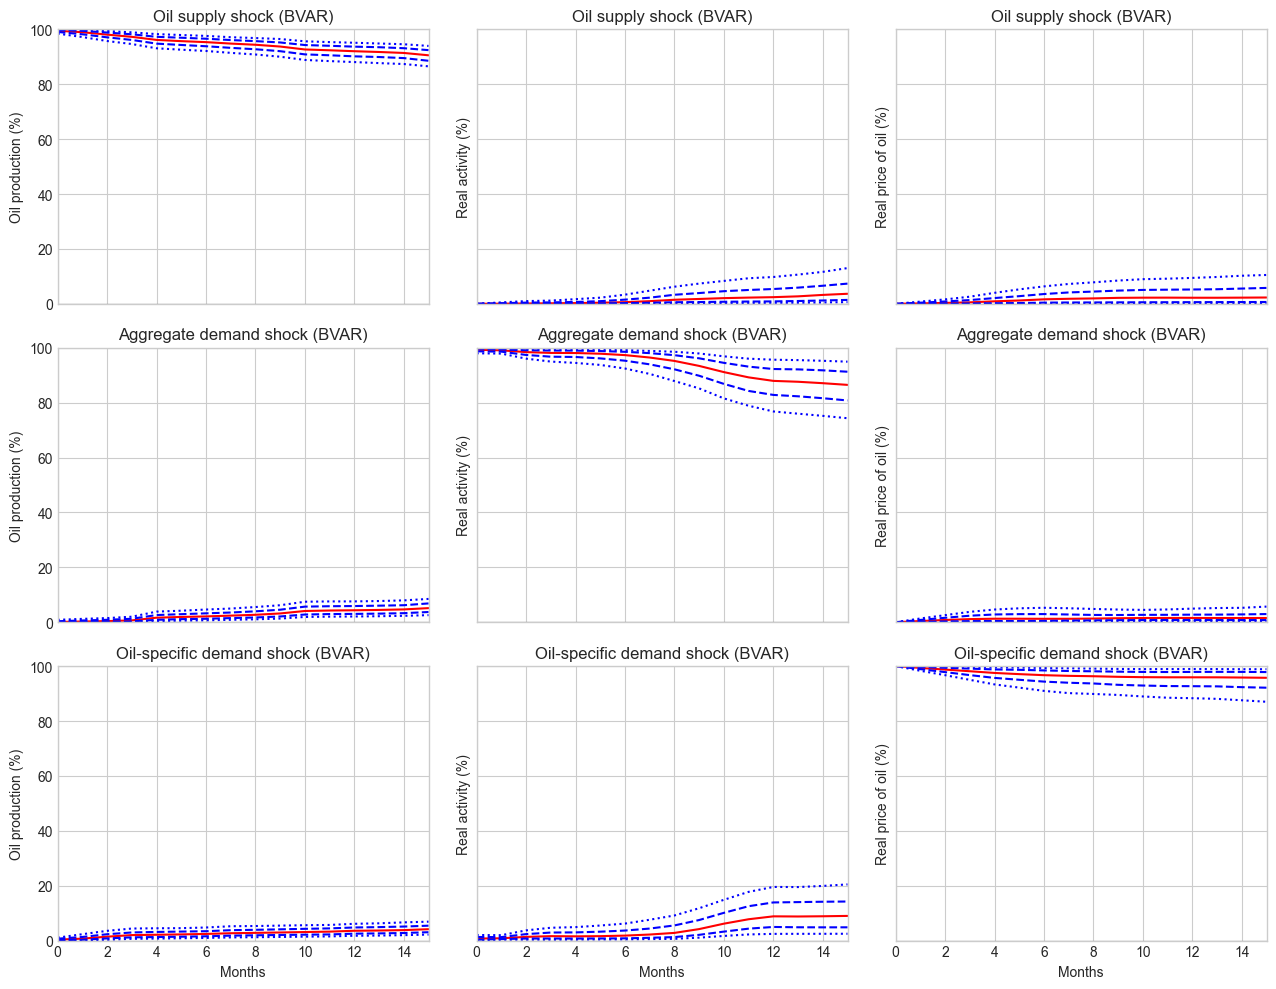

FEVD verification (should sum to ~100% for each variable at each horizon):
Oil production: h=0: 99.9%, h=6: 99.9%, h=15: 99.8%
Real activity: h=0: 100.0%, h=6: 99.7%, h=15: 99.1%
Real price of oil: h=0: 100.0%, h=6: 99.6%, h=15: 99.6%


In [15]:
# FEVD: posterior draws + credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

# FEVD_draws[d, shock, variable, horizon]
FEVD_draws = np.zeros((max_draws, n, n, h + 1))

for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)

    # irf_d uses order='F': [var1_shock1, var2_shock1, var3_shock1, var1_shock2, ...]
    # Reshape to (variable, shock, horizon) then transpose to (shock, variable, horizon)
    psi = irf_d.reshape(n, n, h + 1, order='F').transpose(1, 0, 2)

    # cumulative squared impulse responses up to horizon t
    cum_sq = np.cumsum(psi ** 2, axis=2)
    denom = np.sum(cum_sq, axis=0, keepdims=True)

    # avoid divide-by-zero at very early horizons
    FEVD_draws[j] = np.divide(cum_sq, denom, out=np.zeros_like(cum_sq), where=denom > 0)

FEVD_med = np.median(FEVD_draws, axis=0)
FEVD_68 = np.quantile(FEVD_draws, [0.16, 0.84], axis=0)
FEVD_95 = np.quantile(FEVD_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production'),
    ('Oil supply shock (BVAR)', 'Real activity'),
    ('Oil supply shock (BVAR)', 'Real price of oil'),
    ('Aggregate demand shock (BVAR)', 'Oil production'),
    ('Aggregate demand shock (BVAR)', 'Real activity'),
    ('Aggregate demand shock (BVAR)', 'Real price of oil'),
    ('Oil-specific demand shock (BVAR)', 'Oil production'),
    ('Oil-specific demand shock (BVAR)', 'Real activity'),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil'),
]

for k, (ttl, yl) in enumerate(meta):
    shock = k // n
    var = k % n

    med = 100.0 * FEVD_med[shock, var]
    l68 = 100.0 * FEVD_68[0, shock, var]
    u68 = 100.0 * FEVD_68[1, shock, var]
    l95 = 100.0 * FEVD_95[0, shock, var]
    u95 = 100.0 * FEVD_95[1, shock, var]

    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax = axes[k]
    ax.plot(horizon, med, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(f"{yl} (%)")
    ax.set_xlim(0, h)
    ax.set_ylim(0, 100)
    if k >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

# Verification: FEVD should sum to 100% across shocks for each variable
print("FEVD verification (should sum to ~100% for each variable at each horizon):")
for var in range(n):
    var_names = ['Oil production', 'Real activity', 'Real price of oil']
    fevd_sum = np.sum(FEVD_med[:, var, :], axis=0) * 100
    print(f"{var_names[var]}: h=0: {fevd_sum[0]:.1f}%, h=6: {fevd_sum[6]:.1f}%, h=15: {fevd_sum[15]:.1f}%")


## Bayesian Figure 4: cumulative effect on real oil price

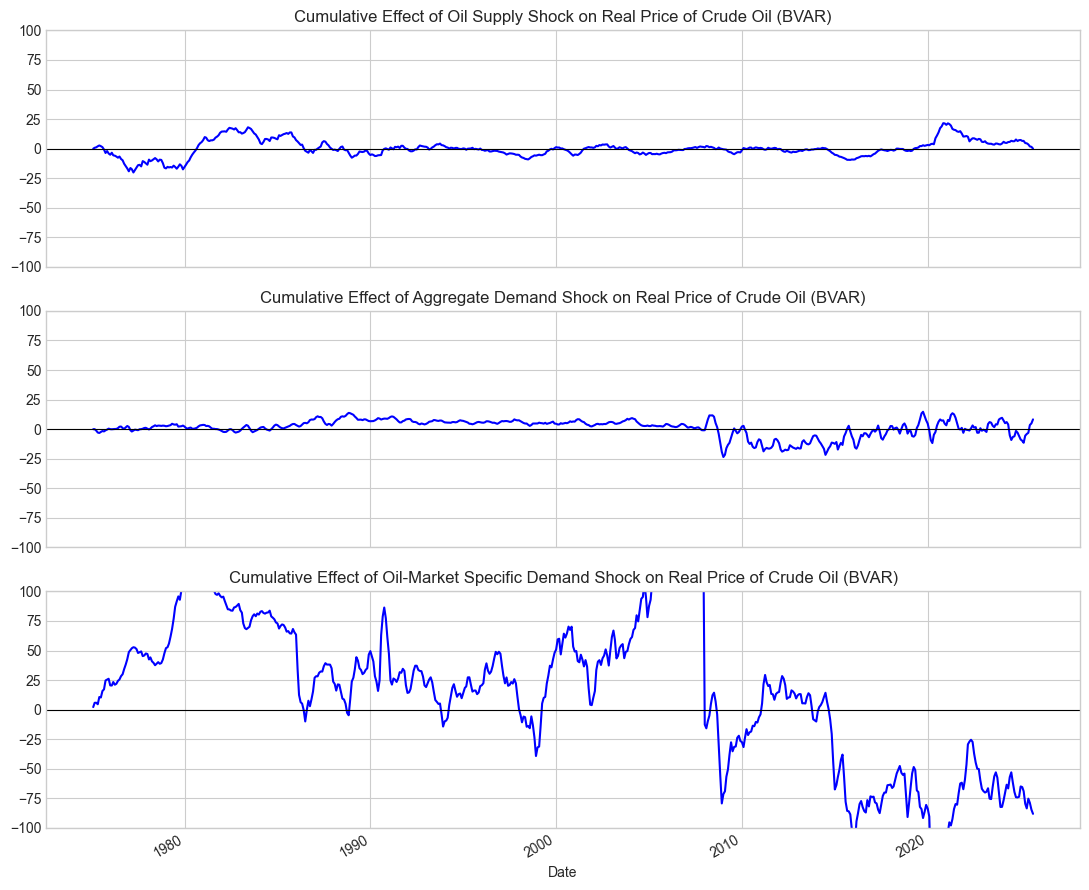

In [16]:
T = y.shape[0]
_, _, A_comp_mean = bvar_state_matrices(bvar['B_mean'], n=n, p=p)
IRF_long = irf_from_companion(A_comp_mean, bvar['Sigma_mean'], n=n, p=p, h=T - p - 1)

yhat1 = np.zeros(T - p)
yhat2 = np.zeros(T - p)
yhat3 = np.zeros(T - p)
for i in range(T - p):
    idx_i = np.arange(i + 1)
    yhat1[i] = np.dot(IRF_long[2, idx_i], Ehat_b[0, i::-1])
    yhat2[i] = np.dot(IRF_long[5, idx_i], Ehat_b[1, i::-1])
    yhat3[i] = np.dot(IRF_long[8, idx_i], Ehat_b[2, i::-1])

# Date axis aligned to the actual data: first shock date is df.index[p]
time_dates = df.index[p:]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

titles = [
    'Cumulative Effect of Oil Supply Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Aggregate Demand Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Oil-Market Specific Demand Shock on Real Price of Crude Oil (BVAR)',
]
for ax, yhat, ttl in zip(axes, [yhat1, yhat2, yhat3], titles):
    ax.plot(time_dates, yhat, 'b-')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylim(-100, 100)

axes[-1].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Bayesian Figure 5-style responses: shocks on real GDP and CPI

In [17]:
# Load merged GDP and CPI data (Kilian's original 1974-2007 + extension 2008-2025)
# These files were created by fetching GDPC1 and CPIAUCSL from FRED

# GDP: quarterly real GDP in billions of chained dollars
beagdp_merged = np.loadtxt(BASE_DIR / 'beagdp_merged_1974_2025.txt')
print("GDP data loaded:")
print(f"  Range: {int(beagdp_merged[0,0])} Q{int(beagdp_merged[0,1])} → "
      f"{int(beagdp_merged[-1,0])} Q{int(beagdp_merged[-1,1])}")
print(f"  Quarters: {len(beagdp_merged)}")

# CPI: monthly CPI-U (all urban consumers)
cpi_merged = np.loadtxt(BASE_DIR / 'cpi_merged_1974_2025.txt')
print("\nCPI data loaded:")
print(f"  Range: {int(cpi_merged[0,0])}-{int(cpi_merged[0,1]):02d} → "
      f"{int(cpi_merged[-1,0])}-{int(cpi_merged[-1,1]):02d}")
print(f"  Months: {len(cpi_merged)}") 


GDP data loaded:
  Range: 1974 Q4 → 2025 Q4
  Quarters: 205

CPI data loaded:
  Range: 1974-12 → 2025-12
  Months: 612



Stage-2 alignment:
  Quarterly shocks : 203 quarters (q1q, q2q, q3q)
  GDP growth       : 203 quarters
  CPI inflation    : 202 quarters
  First quarter    : 1975 Q1
  Used for GDP stage-2: 203 quarters
  Used for CPI stage-2: 202 quarters


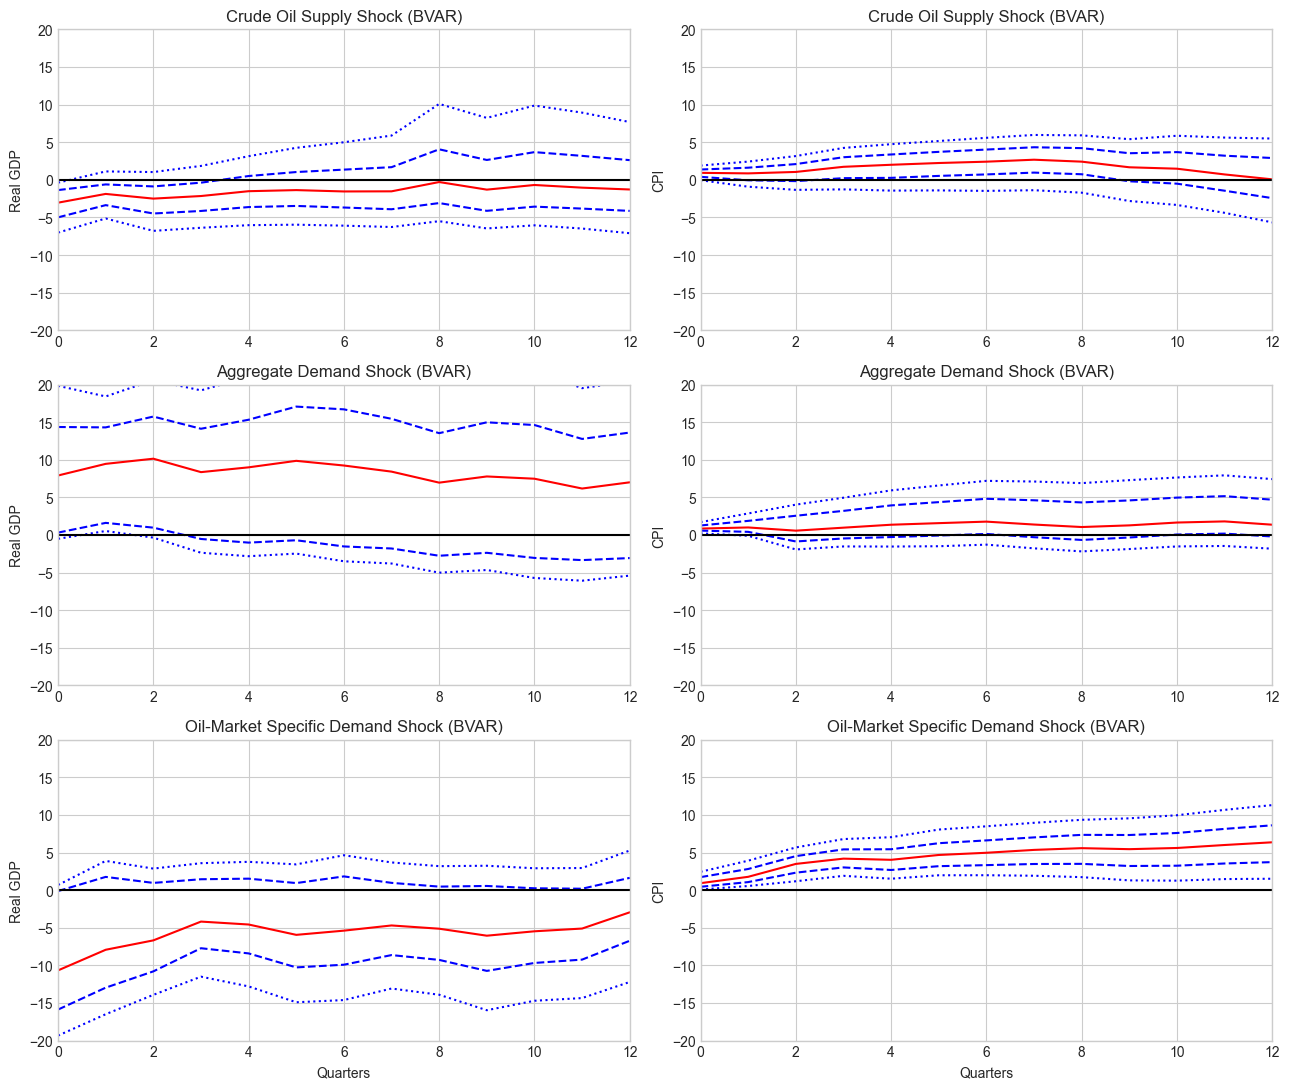

In [18]:
# ═════════════════════════════════════════════════════════════════════════════
# Stage-2 setup: quarterly oil shocks → GDP growth and CPI inflation
# ═════════════════════════════════════════════════════════════════════════════

# Quarterly average structural shocks from monthly BVAR estimates
shock_dates = df.index[p:]  # first shock: 2010-01 (after p=24 lags from 2008-01)

# Pad with initial value (Kilian convention: average first two months)
q1 = np.concatenate([[(Ehat_b[0, 0] + Ehat_b[0, 1]) / 2], Ehat_b[0, :]])
q2 = np.concatenate([[(Ehat_b[1, 0] + Ehat_b[1, 1]) / 2], Ehat_b[1, :]])
q3 = np.concatenate([[(Ehat_b[2, 0] + Ehat_b[2, 1]) / 2], Ehat_b[2, :]])

# Quarterly averages (drop incomplete trailing months)
nq = len(q1) // 3
q1q = q1[:3 * nq].reshape(-1, 3).mean(axis=1)
q2q = q2[:3 * nq].reshape(-1, 3).mean(axis=1)
q3q = q3[:3 * nq].reshape(-1, 3).mean(axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# GDP growth rate (quarterly, annualized %)
# ─────────────────────────────────────────────────────────────────────────────
gdp_vals = beagdp_merged[:, 2]  # column 3: real GDP
y_gdp_full = (np.log(gdp_vals[1:]) - np.log(gdp_vals[:-1])) * 400

# Align with quarterly shocks: first shock quarter is 2010 Q1
first_shock_year = shock_dates[0].year
first_shock_qtr = (shock_dates[0].month - 1) // 3 + 1

gdp_start_year = int(beagdp_merged[0, 0])
gdp_start_qtr = int(beagdp_merged[0, 1])

# Quarters from GDP start to first shock
offset_q = (first_shock_year - gdp_start_year) * 4 + (first_shock_qtr - gdp_start_qtr)

# Extract aligned GDP growth (same length as quarterly shocks)
y_gdp = y_gdp_full[offset_q - 1 : offset_q - 1 + nq, None]

# ─────────────────────────────────────────────────────────────────────────────
# CPI inflation rate (quarterly, annualized %)
# ─────────────────────────────────────────────────────────────────────────────
cpi_vals = cpi_merged[:, 2]
cpi_log = np.log(cpi_vals)

# Quarterly inflation: (log(CPI_end) - log(CPI_start)) × 400 for each quarter
first_cpi_idx = offset_q * 3  # months from CPI start to first shock quarter

infl_q = []
for i in range(nq):
    idx_start = first_cpi_idx + i * 3
    idx_end = idx_start + 3
    if idx_end < len(cpi_log) and not np.isnan(cpi_vals[idx_end]):
        infl_q.append((cpi_log[idx_end] - cpi_log[idx_start]) * 400)
    else:
        # Hit NaN or end of data — stop here
        break

y_cpi = np.array(infl_q)[:, None]

print(f"\nStage-2 alignment:")
print(f"  Quarterly shocks : {nq} quarters (q1q, q2q, q3q)")
print(f"  GDP growth       : {y_gdp.shape[0]} quarters")
print(f"  CPI inflation    : {y_cpi.shape[0]} quarters")
print(f"  First quarter    : {first_shock_year} Q{first_shock_qtr}")

# Align lengths explicitly to avoid mismatch errors in stage2irf
nq_gdp = min(len(q1q), y_gdp.shape[0])
nq_cpi = min(len(q1q), y_cpi.shape[0])

q1q_gdp, q2q_gdp, q3q_gdp = q1q[:nq_gdp], q2q[:nq_gdp], q3q[:nq_gdp]
q1q_cpi, q2q_cpi, q3q_cpi = q1q[:nq_cpi], q2q[:nq_cpi], q3q[:nq_cpi]

y_gdp_use = y_gdp[:nq_gdp]
y_cpi_use = y_cpi[:nq_cpi]

print(f"  Used for GDP stage-2: {nq_gdp} quarters")
print(f"  Used for CPI stage-2: {nq_cpi} quarters")

# Stage-2 responses
nrep_stage2 = 20000
r2 = stage2irf(y_gdp_use, q1q_gdp, nrep=nrep_stage2, seed=42)
r3 = stage2irf(y_gdp_use, q2q_gdp, nrep=nrep_stage2, seed=42)
r4 = stage2irf(y_gdp_use, q3q_gdp, nrep=nrep_stage2, seed=42)

c2 = stage2irf(y_cpi_use, q1q_cpi, nrep=nrep_stage2, seed=42)
c3 = stage2irf(y_cpi_use, q2q_cpi, nrep=nrep_stage2, seed=42)
c4 = stage2irf(y_cpi_use, q3q_cpi, nrep=nrep_stage2, seed=42)

h2 = np.arange(13)
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

# GDP panels
for ax, rr, ttl, sgn in [
    (axes[0, 0], r2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 0], r3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 0], r4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('Real GDP')
    ax.set_title(ttl)
axes[2, 0].set_xlabel('Quarters')

# CPI panels
for ax, rr, ttl, sgn in [
    (axes[0, 1], c2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 1], c3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 1], c4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('CPI')
    ax.set_title(ttl)
axes[2, 1].set_xlabel('Quarters')

plt.tight_layout()
plt.show()